In [1]:
from custom_sharp import create_custom_sharp
import sunpy.map
import sunpy.visualization.colormaps as cm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pathlib

In [3]:
current_dir = str(pathlib.Path.cwd())
print(current_dir)

/home/lucho/GEHMe/lucho_repo/SHARPs/custom_sharp_data_test


In [4]:
azimuth_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.azimuth.fits"
azimuth_err_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.azimuth_err.fits"
field_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.field.fits"
field_err_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.field_err.fits"
inclination_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.inclination.fits"
inclination_err_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.inclination_err.fits"
disambig_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.disambig.fits"
field_az_err_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.field_az_err.fits"
field_inclination_err_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.field_inclination_err.fits"
inclin_azimuth_err_file = current_dir + "/hmi_B_720s/hmi.B_720s.20140801_174800_TAI.inclin_azimuth_err.fits"

/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


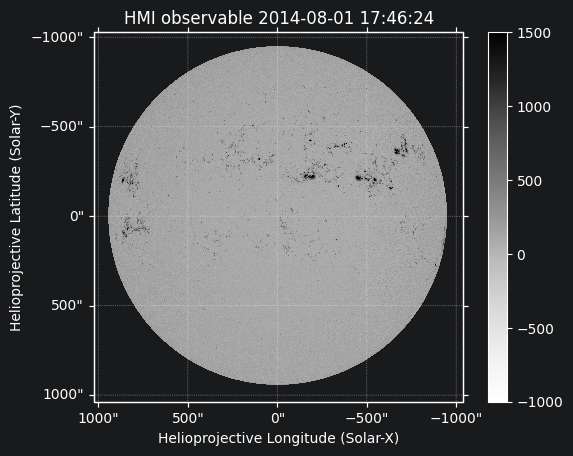

In [5]:
field_map = sunpy.map.Map(field_file)
field_map.peek(vmax=1500,vmin=-1000, cmap=matplotlib.colormaps['Greys'])

In [18]:
print(field_map.meta)

('xtension': 'IMAGE')
('bitpix': '32')
('naxis': '2')
('naxis1': '4096')
('naxis2': '4096')
('pcount': '0')
('gcount': '1')
('blank': '-2147483648')
('t_obs': '2014.08.01_17:48:07.338_TAI')
('t_rec': '2014.08.01_17:48:00.000_TAI')
('trecepoc': '1993.01.01_00:00:00.000_TAI')
('trecstep': '720.0')
('trecunit': 'secs')
('date': '2014-08-09T21:04:16.000')
('date_s': '2014-08-05T23:05:59.000')
('date_me': '2014-08-06T17:06:27.000')
('date-obs': '2014-08-01T17:46:24.800')
('cadence': '720.0')
('telescop': 'SDO/HMI')
('instrume': 'HMI_SIDE1')
('wavelnth': '6173.0')
('camera': '1')
('quality': '0')
('qual_me': '0')
('qual_s': '0')
('quallev1': '0')
('_bunit': 'Mx/cm^2')
('origin': 'SDO/JSOC-SDP')
('content': 'HMI observable')
('history': '')
('comment': 'This FITS file may contain long string keyword values that are
  continued over multiple keywords.  The HEASARC convention uses the &
  character at the end of each substring which is then continued
  on the next keyword which has the name CON

In [7]:
sharp_to_copy_file = current_dir + "/hmi_sharp_cea_720s/hmi.sharp_cea_720s.4396.20140801_174800_TAI.Br.fits"

sharp_map = sunpy.map.Map(sharp_to_copy_file)
center= sharp_map.center
nx = int(sharp_map.dimensions.x.value)
ny = int(sharp_map.dimensions.y.value)


coords_to_use = (center, nx, ny)
print(coords_to_use)

(<SkyCoord (HeliographicCarrington: obstime=2014-08-01T17:47:32.000, rsun=696000.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2014-08-01T17:47:32.000, rsun=696000.0 km): (lon, lat, radius) in (deg, deg, m)
    (0.08350591, 5.809675, 1.517977e+11)>): (lon, lat) in deg
    (224.973526, -14.7281)>, 2465, 956)


In [10]:
br_map,bt_map,bp_map,br_err,bt_err,bp_err = create_custom_sharp.run(b_field=field_file, b_azi=azimuth_file, b_incli=inclination_file, b_disambig=disambig_file,
        b_err_field=field_err_file, b_err_azi=azimuth_err_file, b_err_incli=inclination_err_file,
        b_cc_field_incli=field_inclination_err_file, b_cc_field_azi=field_az_err_file, b_cc_incli_azi=inclin_azimuth_err_file,
        coords=coords_to_use, output_path=current_dir + "/custom_sharp_output")

Creating custom SHARP maps...
Creating custom bp, bt, br maps...
Creating custom bp_err, bt_err, bp_err maps...


/home/lucho/GEHMe/lucho_repo/SHARPs/custom_sharp/cartography.py:46: RuntimeWarning: invalid value encountered in arcsin
  rho = np.arcsin(sinsig / sinang_r) - sig


Saving custom SHARP maps...


OSError: File /home/lucho/GEHMe/lucho_repo/SHARPs/custom_sharp_data_test/custom_sharp_output/hmi.sharp_cea_720s.custom_harp.2014.08.01_17:48:00.000_TAI.Br.fits already exists. If you mean to replace it then use the argument "overwrite=True".

In [12]:
# Let's see if it worked
custom_br_map = sunpy.map.Map(current_dir + "/custom_sharp_output/hmi.sharp_cea_720s.custom_harp.2014.08.01_17:48:00.000_TAI.Br.fits")

/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


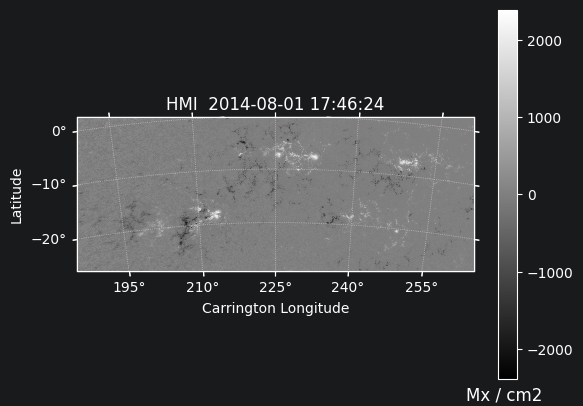

In [13]:
custom_br_map.peek()

In [17]:
print(sharp_map.meta)


('xtension': 'IMAGE')
('bitpix': '32')
('naxis': '2')
('naxis1': '2465')
('naxis2': '956')
('pcount': '0')
('gcount': '1')
('simple': 'True')
('date': '2014-09-06T04:11:04')
('date_s': '2014-08-05T23:05:59Z')
('date_b': '2014-08-09T21:04:16Z')
('date-obs': '2014-08-01T17:46:24.80')
('t_obs': '2014.08.01_17:48:07_TAI')
('t_rec': '2014.08.01_17:48:00_TAI')
('trecepoc': '1993.01.01_00:00:00_TAI')
('trecstep': '720.0')
('trecunit': 'secs')
('cadence': '720.0')
('usflux': '6.018602e+22')
('meangam': '43.003')
('meangbt': '101.459')
('meangbz': '104.353')
('meangbh': '53.24')
('meanjzd': '-0.07936167')
('totusjz': '93699870000000.0')
('meanalp': '0.002631')
('meanjzh': '0.00090827')
('totusjh': '4323.099')
('absnjzh': '90.271')
('savncpp': '4272078000000.0')
('meanpot': '5635.061')
('totpot': '7.438111e+23')
('meanshr': '35.71')
('shrgt45': '26.841')
('r_value': '4.701')
('gwill': 'nan')
('ctype1': 'CRLN-CEA')
('ctype2': 'CRLT-CEA')
('crpix1': '1233.0')
('crpix2': '478.5')
('crval1': '224.97

/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)
/home/lucho/GEHMe/lucho_repo/SHARPs/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


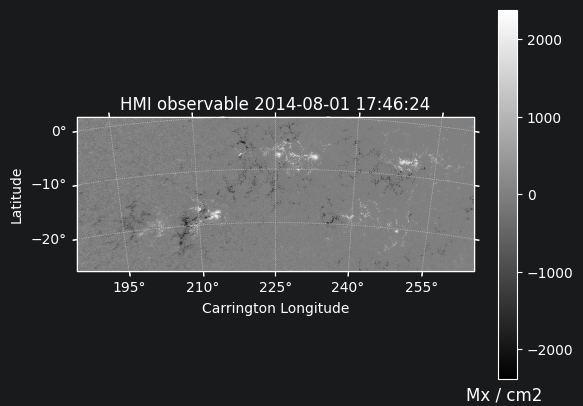

In [14]:
sharp_map.peek()

### Scope and tolerances

Comparing **custom_br_map** with **sharp_map**, using every eligible pixel. Residual = **custom − original**. Agreement means `abs(residual) <= 0.01 + 1e-05 * abs(original)` in the original BUNIT. Grid tolerance: 1e-05 pixels; reference-time tolerance: 0.001 s. Percentage residuals require `abs(original) >= 10.0`; strong-field threshold: 100.0. These thresholds are adjustable diagnostics. Array sums below are **not magnetic flux**. This compares the two loaded Br maps, including their masks and metadata; it does not infer uncertainty significance, reproduce SHARP indices, or inspect other FITS extensions/segments.

### Array, mask, units, time and observer inventory

#### Map inventory

,original,custom
map class,HMIMap,HMIMap
"shape (y,x)","(956, 2465)","(956, 2465)"
stored array dtype,float64,>f8
array bytes,18852320,18852320
unit,Mx / cm2,Mx / cm2
total pixels,2356540,2356540
finite,2356540,2356540
NaN,0,0
+inf,0,0
-inf,0,0


...

#### Agreement by reference polarity and field strength

,pixels,bias,MAE,RMSE,within tolerance (%)
group,,,,,
negative reference,1279812,2.010942099,6.73912483,10.10187866,0.1579919551
zero reference,136,0.1335977164,4.399747323,6.921757819,0
positive reference,1076592,-2.384436588,6.633404452,10.19672178,0.1666369432
0 <= abs(original) < 10,276080,-0.2274083894,4.713128292,7.17909918,0.2137061721
10 <= abs(original) < 100,1638795,-0.1197712653,5.924197109,8.755312558,0.1709792866
100 <= abs(original) < 500,395115,0.5298547169,10.76828531,15.28628955,0.09187198664
500 <= abs(original) < 1000,36640,1.450399848,11.39569689,15.41954856,0.09279475983
1000 <= abs(original) < inf,9910,0.3176493529,8.565783372,12.92412815,0.2724520686


#### 20 largest absolute residuals (zero-based pixel coordinates)

,x,y,world axis 1 (deg),world axis 2 (deg),original,custom,residual,abs residual
0,817,337,211.8627926,-18.58612136,-783.77,-479.6365067,304.1334933,304.1334933
1,816,338,211.8331199,-18.5543589,-771.72,-537.6969459,234.0230541,234.0230541
2,802,337,211.3901753,-18.55971128,263.79,41.21489106,-222.5751089,222.5751089
3,811,337,211.6737301,-18.57566752,-489.75,-697.8419805,-208.0919805,208.0919805
4,810,338,211.6440867,-18.543882,-326.78,-524.4165301,-197.6365301,197.6365301
5,802,338,211.3920747,-18.52968431,568.26,381.3301395,-186.9298605,186.9298605
6,795,324,211.1445121,-18.93750782,112.65,-73.19683311,-185.8468331,185.8468331
7,839,300,212.4913302,-19.7353915,-559.98,-380.6296831,179.3503169,179.3503169
8,809,336,211.6088438,-18.60218008,-1560.29,-1389.107193,171.1828066,171.1828066
9,734,290,209.1454322,-19.84036824,485.28,320.4924061,-164.7875939,164.7875939


### Spatial and distribution diagnostics

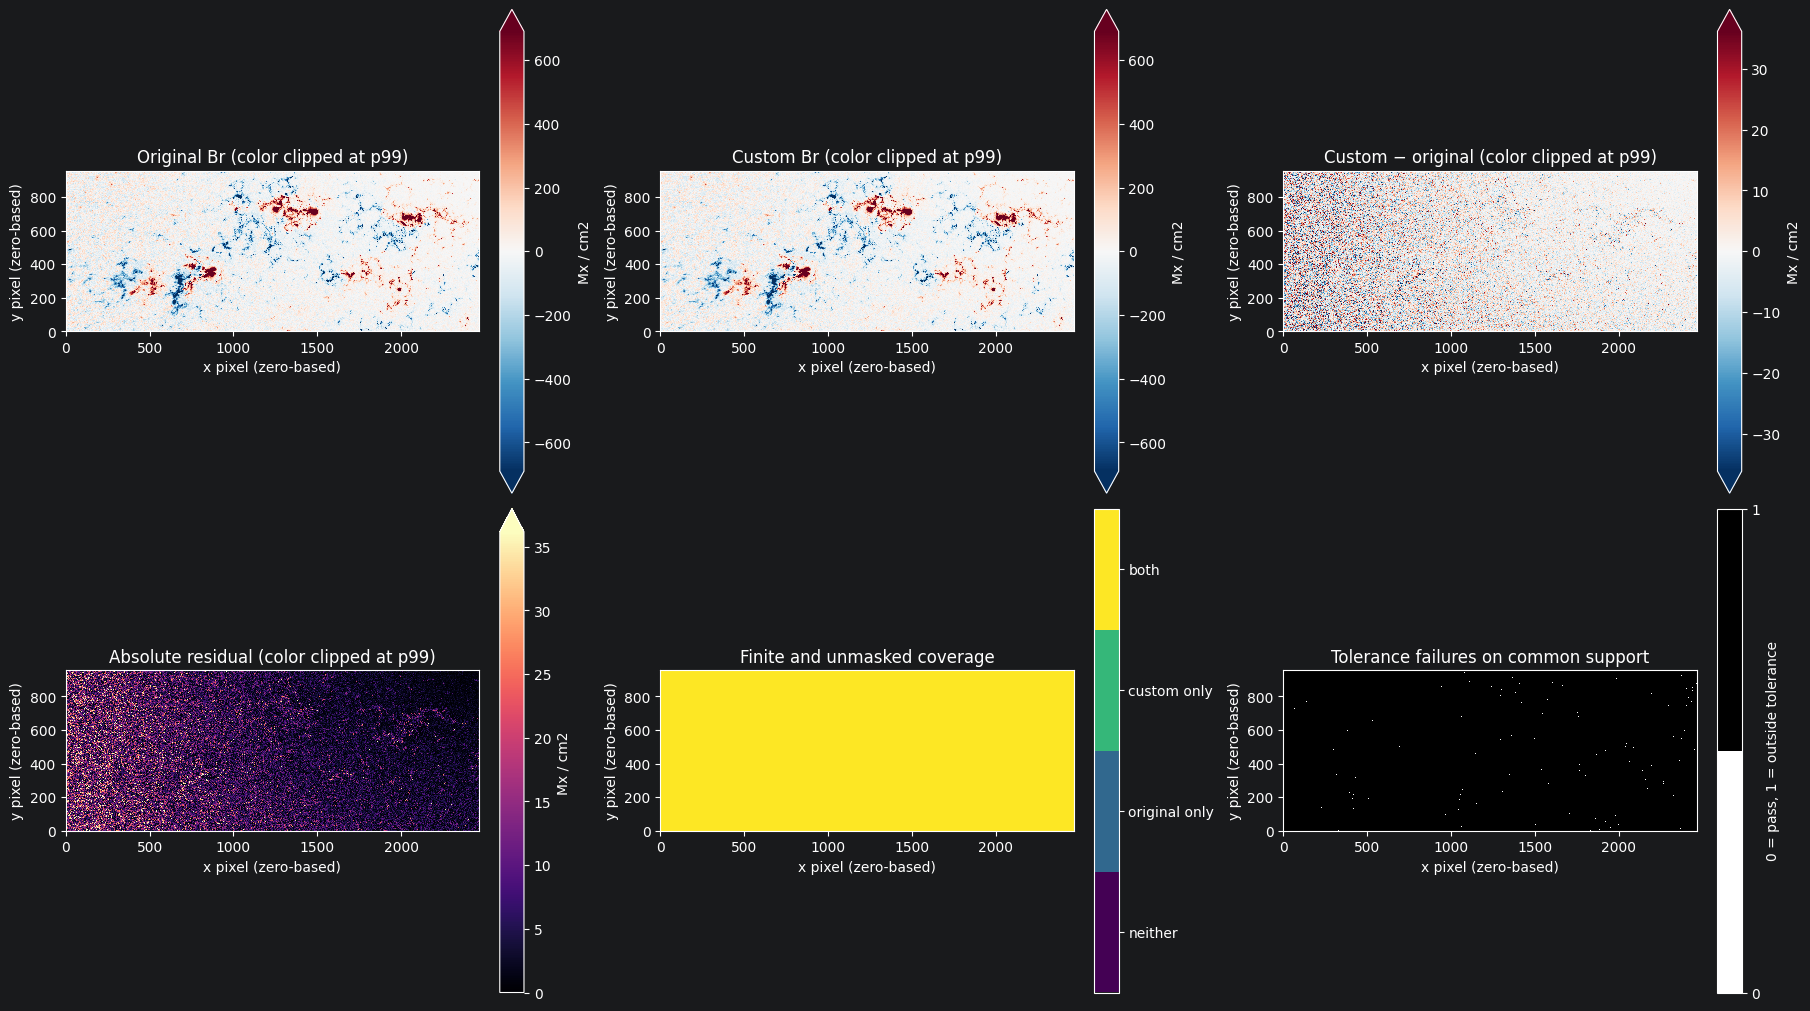

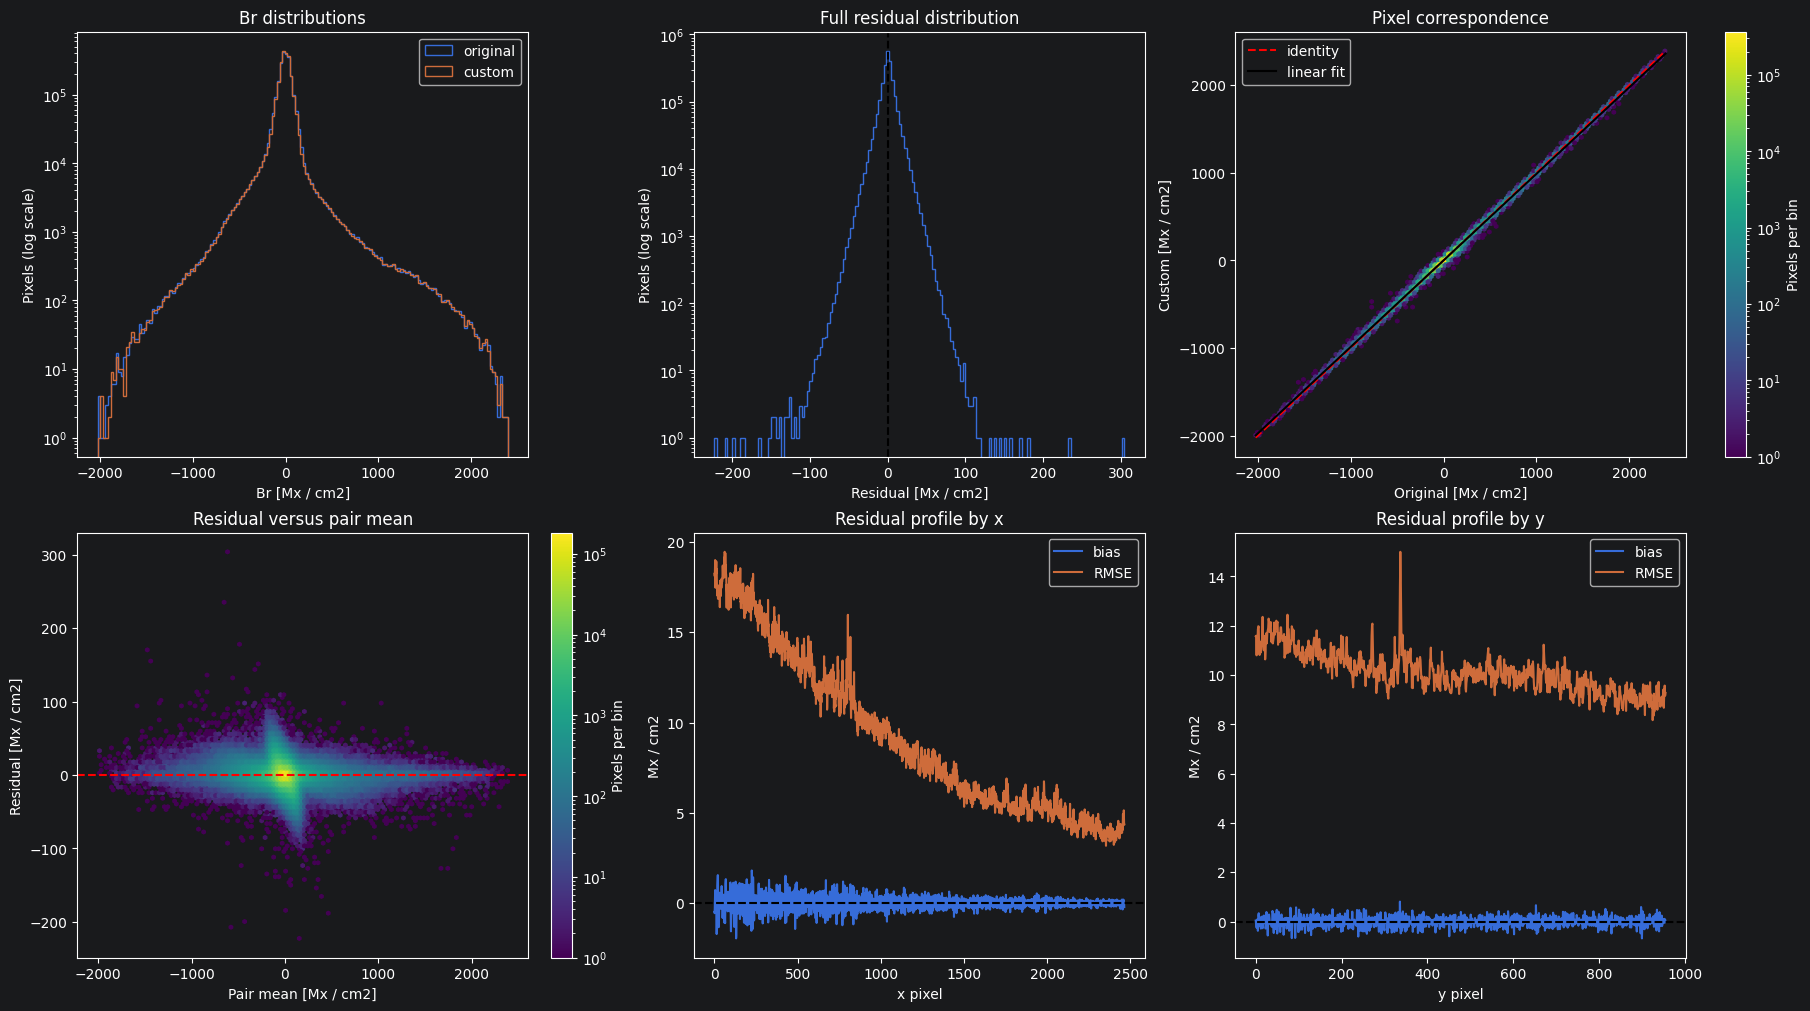

### Computed findings

On **2,356,540 common valid pixels**, the bias is **0.0027925 Mx / cm2**, MAE **6.69069 Mx / cm2**, RMSE **10.1452 Mx / cm2**, and correlation **0.9978815**. **0.1619%** satisfy the stated tolerance. The largest absolute residual is **304.133 Mx / cm2**. Metadata status counts: **{'original only': 145, 'equal': 31, 'different': 17}**. Correlation alone does not establish numerical agreement. Differences in metadata, coverage, scaling and spatial residuals should be assessed together. All tables, the common-valid mask and the residual array are available in `comparison`.

In [16]:
# Comprehensive Br comparison. Re-run after loading custom_br_map and sharp_map.
# Differences are always custom - original; original is the reference.
import html
import numbers

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from sunpy.time import parse_time

# Numerical agreement settings, not measurement-error or science requirements.
ATOL = 0.01                 # in the original map's BUNIT
RTOL = 1e-5
GRID_TOL_PIX = 1e-5
TIME_TOL_S = 1e-3
RELATIVE_FLOOR = 10.0       # omit weak reference pixels from percentage errors
STRONG_FIELD = 100.0        # in the original map's BUNIT
comparison = {}             # all tables and residual arrays remain accessible


def show_table(name, table, expanded=True):
    comparison[name] = table
    body = table.to_html(index=True, escape=True, max_rows=None, max_cols=None,
                         float_format=lambda v: f"{v:.10g}")
    display(Markdown(f"#### {name}"))
    display(HTML(f'<details {"open" if expanded else ""}><summary>'
                 f'{len(table)} rows</summary>{body}</details>'))


def section(text):
    display(Markdown(f"### {text}"))


def ratio(a, b):
    return float(a / b) if b != 0 else np.nan


def describe(values):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if not v.size:
        return {"count": 0}
    q = np.percentile(v, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    result = dict(zip(["min", "p01", "p05", "p25", "median", "p75", "p95", "p99", "max"], q))
    result.update(count=v.size, mean=v.mean(), std_population=v.std(),
                  rms=np.sqrt(np.mean(v**2)), median_absolute_deviation=np.median(abs(v-q[4])),
                  sum=v.sum(), sum_absolute=np.abs(v).sum(), positive=int((v > 0).sum()),
                  negative=int((v < 0).sum()), zero=int((v == 0).sum()))
    return result


def flattened_meta(meta):
    # Include nested keycomments separately, without hiding or truncating any key.
    result = {}
    for k, v in meta.items():
        if isinstance(v, dict):
            result.update({f"{k.lower()}.{str(kk).lower()}": vv for kk, vv in v.items()})
        else:
            result[k.lower()] = v
    return result


def compare_metadata(original, custom):
    rows = []
    for key in sorted(original.keys() | custom.keys()):
        a, b = original.get(key), custom.get(key)
        delta = relative = np.nan
        if key not in original:
            status = "custom only"
        elif key not in custom:
            status = "original only"
        else:
            numeric = (isinstance(a, numbers.Real) and isinstance(b, numbers.Real)
                       and not isinstance(a, (bool, np.bool_)) and not isinstance(b, (bool, np.bool_)))
            equal = bool(np.array_equal(a, b, equal_nan=True)) if numeric else str(a) == str(b)
            status = "equal" if equal else "different"
            if numeric:
                delta = float(b) - float(a)
                relative = ratio(delta, abs(float(a)))
        rows.append({"key": key, "status": status,
                     "original": repr(a) if key in original else "<missing>",
                     "custom": repr(b) if key in custom else "<missing>",
                     "original type": type(a).__name__ if key in original else "—",
                     "custom type": type(b).__name__ if key in custom else "—",
                     "custom-original (numeric)": delta, "relative numeric difference": relative})
    return pd.DataFrame(rows).set_index("key")


section("Scope and tolerances")
display(Markdown(
    f"Comparing **custom_br_map** with **sharp_map**, using every eligible pixel. "
    f"Residual = **custom − original**. Agreement means `abs(residual) <= {ATOL} + "
    f"{RTOL} * abs(original)` in the original BUNIT. Grid tolerance: {GRID_TOL_PIX} pixels; "
    f"reference-time tolerance: {TIME_TOL_S} s. Percentage residuals require "
    f"`abs(original) >= {RELATIVE_FLOOR}`; strong-field threshold: {STRONG_FIELD}. "
    "These thresholds are adjustable diagnostics. Array sums below are **not magnetic flux**. "
    "This compares the two loaded Br maps, including their masks and metadata; it does not "
    "infer uncertainty significance, reproduce SHARP indices, or inspect other FITS extensions/segments."))

maps = {"original": sharp_map, "custom": custom_br_map}
arrays, valid, inventory = {}, {}, {}
for name, m in maps.items():
    data = np.asarray(np.ma.getdata(m.data), dtype=np.float64)
    mask = np.ma.getmaskarray(m.data).copy()
    if m.mask is not None:
        mask |= np.asarray(m.mask, dtype=bool)
    arrays[name] = data
    valid[name] = np.isfinite(data) & ~mask
    inventory[name] = {
        "map class": type(m).__name__, "shape (y,x)": str(data.shape),
        "stored array dtype": str(m.data.dtype), "array bytes": m.data.nbytes,
        "unit": str(m.unit), "total pixels": data.size, "finite": int(np.isfinite(data).sum()),
        "NaN": int(np.isnan(data).sum()), "+inf": int(np.isposinf(data).sum()),
        "-inf": int(np.isneginf(data).sum()), "masked": int(mask.sum()),
        "finite and unmasked": int(valid[name].sum()),
        "valid coverage (%)": 100 * valid[name].mean(),
        "observation time (UTC)": m.date.utc.isot, "WCS reference time (UTC)": m.reference_date.utc.isot,
        "coordinate frame": m.coordinate_frame.name,
        "observer": str(m.observer_coordinate), "solar radius": str(m.rsun_meters),
    }
section("Array, mask, units, time and observer inventory")
show_table("Map inventory", pd.DataFrame(inventory))

unit_ok = sharp_map.unit is not None and custom_br_map.unit is not None
unit_ok = unit_ok and custom_br_map.unit.is_equivalent(sharp_map.unit)
factor = (1 * custom_br_map.unit).to_value(sharp_map.unit) if unit_ok else np.nan
unit_label = str(sharp_map.unit)
original = arrays["original"]
custom = arrays["custom"] * factor if unit_ok else arrays["custom"]
show_table("Independent valid-pixel distributions", pd.DataFrame({
    "original (native unit)": describe(original[valid["original"]]),
    "custom (original unit)" if unit_ok else "custom (native unit; NOT comparable)":
        describe(custom[valid["custom"]]),
}))

section("Every metadata field, including comments and provenance")
metadata = compare_metadata(flattened_meta(sharp_map.meta), flattened_meta(custom_br_map.meta))
show_table("Metadata status counts", metadata.groupby("status").size().to_frame("keys"))
show_table("Metadata differences and missing keys", metadata[metadata.status != "equal"])
show_table("Complete metadata audit (including equal keys)", metadata, expanded=False)
show_table("Normalized WCS header audit", compare_metadata(
    {k.lower(): v for k, v in sharp_map.wcs.to_header(relax=True).items()},
    {k.lower(): v for k, v in custom_br_map.wcs.to_header(relax=True).items()}), expanded=False)

# Raw strings remain in the audit; parse times separately to distinguish formatting from real changes.
time_rows = []
time_keys = {"date", "date-obs", "date_obs", "date_s", "date_b", "date-avg", "date-beg", "date-end",
             "t_obs", "t_rec", "trecepoc", "t_frst", "t_frst1", "t_last", "t_last1"}
for key in sorted(time_keys & (sharp_map.meta.keys() | custom_br_map.meta.keys())):
    row = {"key": key}
    parsed = {}
    for name, m in maps.items():
        value = m.meta.get(key)
        try:
            if value is not None:
                # JSOC suffixes explicitly specify TAI; otherwise honor TIMESYS, default UTC.
                scale = "tai" if "TAI" in str(value) else str(m.meta.get("timesys", "utc")).lower()
                parsed[name] = parse_time(value, scale=scale)
                row[f"{name} UTC"] = parsed[name].utc.isot
            else:
                row[f"{name} UTC"] = "<missing>"
        except (ValueError, TypeError) as exc:
            row[f"{name} UTC"] = f"unparsed: {exc}"
    row["custom-original (s)"] = ((parsed["custom"] - parsed["original"]).to_value(u.s)
                                     if len(parsed) == 2 else np.nan)
    time_rows.append(row)
show_table("Time values normalized to UTC", pd.DataFrame(time_rows).set_index("key"))

# Check published summary cards against the loaded data, before unit conversion.
header_rows = []
for name, m in maps.items():
    a = arrays[name]
    v = a[np.isfinite(a)]
    measured = {"naxis1": a.shape[1], "naxis2": a.shape[0], "datavals": v.size,
                "missvals": a.size-v.size}
    if v.size:
        measured.update(datamin=v.min(), datamax=v.max(), datamedn=np.median(v), datamean=v.mean())
    for key, computed in measured.items():
        stored = m.meta.get(key)
        header_rows.append({"map": name, "key": key, "header": stored, "computed": computed,
                            "computed-header": computed-float(stored) if stored is not None else np.nan})
show_table("Header consistency (finite data, masks ignored)", pd.DataFrame(header_rows))
display(Markdown("`DATARMS` is retained in the metadata audit; both RMS about zero and standard "
                 "deviation are computed above without assuming which convention that header uses. "
                 "Missing SHARP summary fields are reported, not reconstructed from Br alone."))

section("Coordinate registration across the full pixel grid")
same_shape = original.shape == custom.shape
reference_dt = (custom_br_map.reference_date-sharp_map.reference_date).to_value(u.s)
observer_distance = np.linalg.norm(
    (custom_br_map.observer_coordinate.cartesian.xyz -
     sharp_map.observer_coordinate.cartesian.xyz).to_value(u.m))
axes_ok = (list(sharp_map.wcs.wcs.ctype) == list(custom_br_map.wcs.wcs.ctype)
           and list(sharp_map.wcs.wcs.cunit) == list(custom_br_map.wcs.wcs.cunit))
frame_ok = sharp_map.coordinate_frame.name == custom_br_map.coordinate_frame.name
grid_max, grid_sum_sq, grid_count, grid_bad = 0.0, 0.0, 0, 0
grid_error = ""
if same_shape and axes_ok and frame_ok:
    try:
        # Transform every original pixel center through world coordinates to the custom grid.
        # Chunk rows to avoid allocating full-resolution coordinate objects for both maps.
        for start in range(0, original.shape[0], 64):
            yy, xx = np.mgrid[start:min(start+64, original.shape[0]), :original.shape[1]]
            world = sharp_map.wcs.pixel_to_world_values(xx, yy)
            cx, cy = custom_br_map.wcs.world_to_pixel_values(*world)
            offset = np.hypot(cx-xx, cy-yy)
            finite = np.isfinite(offset)
            grid_bad += int((~finite).sum())
            if finite.any():
                grid_max = max(grid_max, float(offset[finite].max()))
                grid_sum_sq += float(np.sum(offset[finite]**2))
                grid_count += int(finite.sum())
    except (ValueError, TypeError, RuntimeError) as exc:
        grid_error = f"{type(exc).__name__}: {exc}"
grid_ok = (same_shape and axes_ok and frame_ok and not grid_error and grid_bad == 0
           and grid_count == original.size and grid_max <= GRID_TOL_PIX)
time_ok = abs(reference_dt) <= TIME_TOL_S
show_table("Registration checks", pd.DataFrame({"value": {
    "same shape": same_shape, "compatible units": unit_ok, "custom unit conversion factor": factor,
    "same WCS axis types and units": axes_ok, "same coordinate-frame name": frame_ok,
    "reference-time difference (s)": reference_dt, "reference time within tolerance": time_ok,
    "observer Cartesian difference (m; native frame axes)": observer_distance,
    "solar-radius difference (m)": (custom_br_map.rsun_meters-sharp_map.rsun_meters).to_value(u.m),
    "finite transformed pixel centers": grid_count, "nonfinite transformed centers": grid_bad,
    "maximum grid offset (pixel)": grid_max if grid_count else np.nan,
    "RMS grid offset (pixel)": np.sqrt(ratio(grid_sum_sq, grid_count)),
    "grid aligned within tolerance": grid_ok, "grid transform error": grid_error or "none",
}}))
display(Markdown("The grid test checks the numerical WCS at every pixel center. Time, observer and "
                 "solar-radius differences are shown separately; matching pixel grids alone does not "
                 "establish identical observing geometry. No reprojection or resampling is applied."))

if same_shape and axes_ok and frame_ok:
    try:
        height, width = original.shape
        px = np.array([0, width-1, 0, width-1, (width-1)/2])
        py = np.array([0, 0, height-1, height-1, (height-1)/2])
        world_original = sharp_map.pixel_to_world(px*u.pix, py*u.pix)
        world_custom = custom_br_map.pixel_to_world(px*u.pix, py*u.pix)
        transformed = custom_br_map.world_to_pixel(world_original)
        show_table("Corners and center, including coordinate-frame transformation", pd.DataFrame({
            "point": ["bottom left", "bottom right", "top left", "top right", "center"],
            "x": px, "y": py,
            "original longitude (deg)": world_original.spherical.lon.to_value(u.deg),
            "original latitude (deg)": world_original.spherical.lat.to_value(u.deg),
            "custom longitude (deg)": world_custom.spherical.lon.to_value(u.deg),
            "custom latitude (deg)": world_custom.spherical.lat.to_value(u.deg),
            "frame-transformed dx (pixel)": transformed.x.to_value(u.pix)-px,
            "frame-transformed dy (pixel)": transformed.y.to_value(u.pix)-py,
        }).set_index("point"))
    except (ValueError, TypeError, RuntimeError) as exc:
        display(Markdown(f"Coordinate-frame transformation unavailable: `{type(exc).__name__}: {exc}`"))
if not time_ok:
    display(Markdown(
        f"**Reference times differ by {reference_dt:.6g} s.** The numerical comparison below is "
        "at matching array indices on the numerical WCS grid. It is not a time-corrected "
        "comparison of identical solar locations; inspect the frame-transformed offsets above."))

if not (same_shape and unit_ok and grid_ok):
    display(Markdown("**Pixel residual analysis skipped:** shapes, units or numerical grid "
                     "registration are incompatible. Resolve these checks before interpreting pixel differences."))
else:
    section("Pixel agreement on the common finite, unmasked support")
    common = valid["original"] & valid["custom"]
    show_table("Coverage overlap", pd.DataFrame({"pixels": {
        "both valid": int(common.sum()),
        "only original valid": int((valid["original"] & ~valid["custom"]).sum()),
        "only custom valid": int((valid["custom"] & ~valid["original"]).sum()),
        "neither valid": int((~valid["custom"] & ~valid["original"]).sum()),
    }}))
    show_table("Validity-pattern equality", pd.DataFrame({"equal at every pixel": {
        "NaN locations": np.array_equal(np.isnan(original), np.isnan(custom)),
        "+infinity locations": np.array_equal(np.isposinf(original), np.isposinf(custom)),
        "-infinity locations": np.array_equal(np.isneginf(original), np.isneginf(custom)),
        "finite and unmasked support": np.array_equal(valid["original"], valid["custom"]),
    }}))
    comparison["common_valid_mask"] = common
    if not common.any():
        display(Markdown("**No common valid pixels:** residual metrics and paired plots are undefined."))
    else:
        a, b = original[common], custom[common]
        d = b-a
        absolute = abs(d)
        agrees = np.isclose(b, a, atol=ATOL, rtol=RTOL)
        centered_a, centered_b = a-a.mean(), b-b.mean()
        slope = ratio(np.dot(centered_a, centered_b), np.dot(centered_a, centered_a))
        intercept = b.mean()-slope*a.mean()
        pearson = ratio(np.dot(centered_a, centered_b),
                        np.sqrt(np.dot(centered_a, centered_a)*np.dot(centered_b, centered_b)))
        metrics = {
            "common pixels": a.size, "exact equality (%)": 100*np.mean(a == b),
            "within ATOL + RTOL*abs(original) (%)": 100*agrees.mean(),
            "outside tolerance (pixels)": int((~agrees).sum()), "bias / mean residual": d.mean(),
            "MAE": absolute.mean(), "RMSE": np.sqrt(np.mean(d**2)),
            "RMSE / original RMS": ratio(np.sqrt(np.mean(d**2)), np.sqrt(np.mean(a**2))),
            "median residual": np.median(d), "residual standard deviation": d.std(),
            "absolute residual p95": np.percentile(absolute, 95),
            "absolute residual p99": np.percentile(absolute, 99), "max absolute residual": absolute.max(),
            "Pearson correlation": pearson, "fit custom = slope*original + intercept: slope": slope,
            "fit intercept": intercept,
            "agreement R² = 1-SSE/SST(original)": 1-ratio(np.sum(d**2), np.sum(centered_a**2)),
            "sign mismatch including zero (%)": 100*np.mean(np.sign(a) != np.sign(b)),
            "opposite nonzero polarities (%)": 100*np.mean(a*b < 0),
            "original signed pixel sum": a.sum(), "custom signed pixel sum": b.sum(),
            "original absolute pixel sum": abs(a).sum(), "custom absolute pixel sum": abs(b).sum(),
        }
        strong = abs(a) >= STRONG_FIELD
        relative_mask = abs(a) >= RELATIVE_FLOOR
        metrics["strong-reference pixels"] = int(strong.sum())
        metrics["strong-reference sign mismatch (%)"] = 100*np.mean(np.sign(a[strong]) != np.sign(b[strong])) if strong.any() else np.nan
        metrics["relative-error eligible pixels"] = int(relative_mask.sum())
        metrics["median absolute percentage error above floor (%)"] = np.median(100*absolute[relative_mask]/abs(a[relative_mask])) if relative_mask.any() else np.nan
        show_table("Agreement metrics", pd.DataFrame({"value": metrics}))
        show_table("Common-support distributions", pd.DataFrame({"original": describe(a), "custom": describe(b),
                                                                "residual": describe(d), "absolute residual": describe(absolute)}))
        group_rows = []
        selections = {"negative reference": a < 0, "zero reference": a == 0, "positive reference": a > 0}
        for lo, hi in [(0, 10), (10, 100), (100, 500), (500, 1000), (1000, np.inf)]:
            selections[f"{lo} <= abs(original) < {hi}"] = (abs(a) >= lo) & (abs(a) < hi)
        for label, select in selections.items():
            v = d[select]
            group_rows.append({"group": label, "pixels": v.size,
                               "bias": v.mean() if v.size else np.nan,
                               "MAE": abs(v).mean() if v.size else np.nan,
                               "RMSE": np.sqrt(np.mean(v**2)) if v.size else np.nan,
                               "within tolerance (%)": 100*agrees[select].mean() if v.size else np.nan})
        show_table("Agreement by reference polarity and field strength", pd.DataFrame(group_rows).set_index("group"))

        residual = np.full(original.shape, np.nan)
        residual[common] = d
        comparison["residual"] = residual
        worst = np.argsort(absolute)[-20:][::-1]
        wy, wx = np.unravel_index(np.flatnonzero(common)[worst], original.shape)
        lon, lat = sharp_map.wcs.pixel_to_world_values(wx, wy)
        show_table("20 largest absolute residuals (zero-based pixel coordinates)", pd.DataFrame({
            "x": wx, "y": wy, "world axis 1 (deg)": lon, "world axis 2 (deg)": lat,
            "original": a[worst], "custom": b[worst], "residual": d[worst], "abs residual": absolute[worst]}))

        section("Spatial and distribution diagnostics")
        field_limit = max(float(np.percentile(np.r_[abs(a), abs(b)], 99)), np.finfo(float).eps)
        diff_limit = max(float(np.percentile(absolute, 99)), np.finfo(float).eps)
        coverage = valid["original"].astype(int) + 2*valid["custom"].astype(int)
        fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
        for ax, data, title, limit in [
            (axes[0, 0], np.where(valid["original"], original, np.nan), "Original Br", field_limit),
            (axes[0, 1], np.where(valid["custom"], custom, np.nan), "Custom Br", field_limit),
            (axes[0, 2], residual, "Custom − original", diff_limit),
        ]:
            im = ax.imshow(data, origin="lower", cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest")
            fig.colorbar(im, ax=ax, label=unit_label, extend="both")
            ax.set_title(title + " (color clipped at p99)")
        im = axes[1, 0].imshow(abs(residual), origin="lower", cmap="magma", vmin=0, vmax=diff_limit, interpolation="nearest")
        fig.colorbar(im, ax=axes[1, 0], label=unit_label, extend="max")
        axes[1, 0].set_title("Absolute residual (color clipped at p99)")
        im = axes[1, 1].imshow(coverage, origin="lower", cmap=plt.get_cmap("viridis", 4), vmin=-0.5, vmax=3.5, interpolation="nearest")
        cb = fig.colorbar(im, ax=axes[1, 1], ticks=[0, 1, 2, 3])
        cb.ax.set_yticklabels(["neither", "original only", "custom only", "both"])
        axes[1, 1].set_title("Finite and unmasked coverage")
        failure = np.full(original.shape, np.nan)
        failure[common] = ~agrees
        im = axes[1, 2].imshow(failure, origin="lower", cmap=plt.get_cmap("Greys", 2), vmin=0, vmax=1, interpolation="nearest")
        fig.colorbar(im, ax=axes[1, 2], ticks=[0, 1], label="0 = pass, 1 = outside tolerance")
        axes[1, 2].set_title("Tolerance failures on common support")
        for ax in axes.flat:
            ax.set_xlabel("x pixel (zero-based)")
            ax.set_ylabel("y pixel (zero-based)")
        plt.show()

        fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
        # Histograms/hexbin use all common pixels, with full value ranges.
        edges = np.histogram_bin_edges(np.r_[a, b], bins=160)
        axes[0, 0].hist(a, bins=edges, histtype="step", label="original")
        axes[0, 0].hist(b, bins=edges, histtype="step", label="custom")
        axes[0, 0].set(xlabel=f"Br [{unit_label}]", ylabel="Pixels (log scale)", yscale="log", title="Br distributions")
        axes[0, 0].legend()
        axes[0, 1].hist(d, bins=160, histtype="step")
        axes[0, 1].axvline(0, color="black", ls="--")
        axes[0, 1].set(xlabel=f"Residual [{unit_label}]", ylabel="Pixels (log scale)", yscale="log", title="Full residual distribution")
        hb = axes[0, 2].hexbin(a, b, gridsize=120, bins="log", mincnt=1)
        line = np.array([min(a.min(), b.min()), max(a.max(), b.max())])
        axes[0, 2].plot(line, line, "r--", label="identity")
        if np.isfinite(slope):
            axes[0, 2].plot(line, slope*line+intercept, "k-", label="linear fit")
        axes[0, 2].legend()
        axes[0, 2].set(xlabel=f"Original [{unit_label}]", ylabel=f"Custom [{unit_label}]", title="Pixel correspondence")
        fig.colorbar(hb, ax=axes[0, 2], label="Pixels per bin")
        hb = axes[1, 0].hexbin((a+b)/2, d, gridsize=120, bins="log", mincnt=1)
        axes[1, 0].axhline(0, color="r", ls="--")
        axes[1, 0].set(xlabel=f"Pair mean [{unit_label}]", ylabel=f"Residual [{unit_label}]", title="Residual versus pair mean")
        fig.colorbar(hb, ax=axes[1, 0], label="Pixels per bin")
        for ax, axis, label in [(axes[1, 1], 0, "x"), (axes[1, 2], 1, "y")]:
            count = common.sum(axis=axis)
            mean = np.divide(np.nansum(residual, axis=axis), count,
                             out=np.full(count.shape, np.nan), where=count > 0)
            rmse = np.sqrt(np.divide(np.nansum(residual**2, axis=axis), count,
                                    out=np.full(count.shape, np.nan), where=count > 0))
            ax.plot(mean, label="bias")
            ax.plot(rmse, label="RMSE")
            ax.axhline(0, color="black", ls="--")
            ax.set(xlabel=f"{label} pixel", ylabel=unit_label, title=f"Residual profile by {label}")
            ax.legend()
        plt.show()
        section("Computed findings")
        display(Markdown(
            f"On **{a.size:,} common valid pixels**, the bias is **{d.mean():.6g} {unit_label}**, "
            f"MAE **{absolute.mean():.6g} {unit_label}**, RMSE **{np.sqrt(np.mean(d**2)):.6g} {unit_label}**, "
            f"and correlation **{pearson:.8g}**. **{100*agrees.mean():.4f}%** satisfy the stated tolerance. "
            f"The largest absolute residual is **{absolute.max():.6g} {unit_label}**. "
            f"Metadata status counts: **{metadata.status.value_counts().to_dict()}**. "
            "Correlation alone does not establish numerical agreement. Differences in metadata, "
            "coverage, scaling and spatial residuals should be assessed together. "
            "All tables, the common-valid mask and the residual array are available in `comparison`."))
